Piecewise_Model


Running ess...
 10.556903 seconds (187.34 M allocations: 5.619 GiB, 14.04% gc time, 3.20% compilation time)
Running mh...
  7.176268 seconds (139.75 M allocations: 4.379 GiB, 10.16% gc time, 0.55% compilation time)
Running is...
  0.637637 seconds (16.02 M allocations: 568.752 MiB, 21.46% gc time)
Log Likelihood (ess): -142.94900138253564
Log Likelihood (mh): 10.229790861919245
Log Likelihood (is): -139.23147461171686


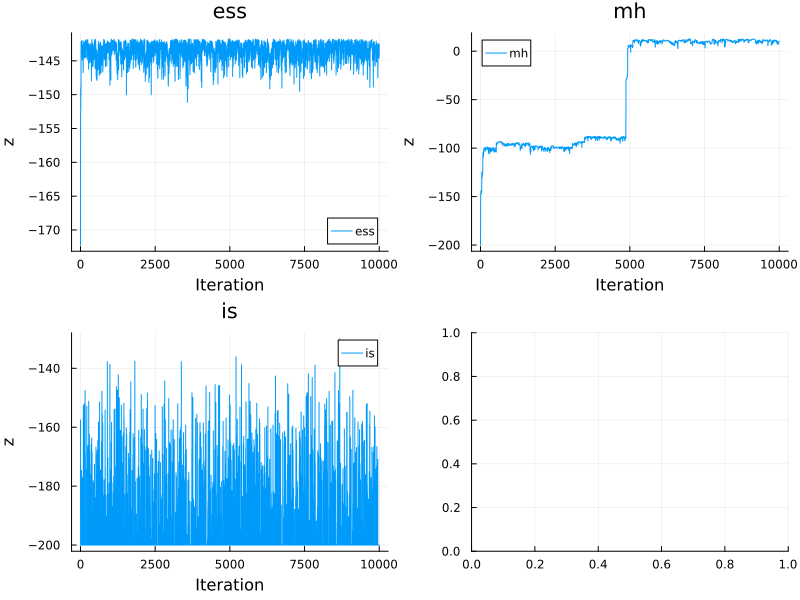

In [4]:

using Gen, Distributions, Plots, StatsPlots

# A distribution that is guaranteed to be 1 or higher.
@dist poisson_plus_one(rate) = poisson(rate) + 1;

function logmeanexp(scores)
    logsumexp(scores) - log(length(scores))
end;

# Define the piecewise_constant model
@gen function piecewise_constant(xs::Vector{Float64})
    # Generate a number of segments (at least 1)
    segment_count ~ poisson_plus_one(1)
    
    # Draw a vector on the simplex from a Dirichlet distribution
    fractions ~ Gen.dirichlet(ones(segment_count))

    # Generate values for each segment
    segments = [{(:segments, i)} ~ normal(0, 1) for i=1:segment_count]
    
    # Determine a global noise level (gamma-distributed)
    z ~ normal(0, 1)  # z is Normally distributed
    noise = quantile(Gamma(1, 1), cdf(Normal(0, 1), z))  # Transform z to noise using the gamma CDF
    
    # Generate the y points for the input x points
    xmin, xmax = extrema(xs)
    cumfracs = cumsum(fractions)
    cumfracs[end] = 1.0  # Ensure the last cumulative fraction is exactly 1.0

    inds = [findfirst(frac -> frac >= (x - xmin) / (xmax - xmin), cumfracs) for x in xs]
    segment_values = segments[inds]
    for (i, val) in enumerate(segment_values)
        {(:y, i)} ~ normal(val, noise)
    end
end

# Generalized Elliptical Slice Sampling (ESS)
function elliptical_slice_sampling(tr, model, args, observations, addresses, prior_dict)
    # Current parameter value(s) for the selected addresses
    current_values = [get_choices(tr)[addr] for addr in addresses]

    # Extract prior mean (m0) and variance (t2) for each selected address
    prior_means = []
    prior_vars = []
    for addr in addresses
        # Get the prior distribution for the selected address
        prior_dist = prior_dict[addr]
        # Extract mean and variance from the prior distribution
        if prior_dist isa Normal
            push!(prior_means, prior_dist.μ)
            push!(prior_vars, prior_dist.σ^2)
        else
            error("Prior distribution for $addr is not Normal. ESS requires Normal priors.")
        end
    end

    # Standard deviations for the priors
    prior_stds = sqrt.(prior_vars)

    # Center the current values so the priors are ~N(0, prior_std^2)
    current_values_offset = current_values .- prior_means

    # Sample a random "direction" from the same priors: N(0, prior_std^2)
    nu = prior_stds .* randn(length(current_values))

    # Current log probability (includes prior + likelihood)
    logp_cur = Gen.get_score(tr)

    # Slice threshold: uniformly pick a threshold below logp_cur
    logy = logp_cur + log(rand())

    # Draw an initial angle
    theta = 2π * rand()
    # Bracket is [theta - 2π, theta]
    theta_min = theta - 2π
    theta_max = theta

    # Elliptical slice loop
    while true
        # Proposed offset via "rotation"
        proposed_offset = current_values_offset .* cos(theta) + nu .* sin(theta)
        # Shift back by prior means
        proposed_values = prior_means .+ proposed_offset

        # Create a ChoiceMap with the proposed values
        temp_cm = Gen.choicemap()
        for (i, addr) in enumerate(addresses)
            temp_cm[addr] = proposed_values[i]
        end

        # Attempt to update the trace with the new values
        (temp_tr, _, re_score) = Gen.update(tr, args, (), temp_cm)

        # Ensure re_score is a numeric type
        re_score = Float64(Gen.get_score(temp_tr))

        if re_score > logy
            # Accept the proposal
            return temp_tr
        else
            # Shrink the bracket
            if theta < 0
                theta_min = theta
            else
                theta_max = theta
            end
            # Sample a new angle within the bracket
            theta = rand() * (theta_max - theta_min) + theta_min
        end
    end
end

# Function to compute log likelihood
function compute_log_likelihood(traces)
    log_likelihoods = [get_score(tr) for tr in traces]
    mean_log_likelihood = logmeanexp(log_likelihoods)
    return mean_log_likelihood
end

# Function to run inference
function run_inference(method, model, args, observations, addresses, prior_dict, num_samples)
    traces = []
    (tr, _) = generate(model, args, observations)
    
    if method == :is
        traces, _ = importance_sampling(model, args, observations, num_samples)
        return traces
    end
    for iter=1:num_samples
        if method == :ess
            tr = elliptical_slice_sampling(tr, model, args, observations, addresses, prior_dict)
        elseif method == :mh
            tr, = mh(tr, select(:segment_count, :fractions))
            tr, = mh(tr, select(:fractions))
            tr, = mh(tr, select(:z, :noise))
            for i=1:tr[:segment_count]
                tr, = mh(tr, select((:segments, i)))
            end
        elseif method == :hmc
            (tr, _) = hmc(tr, select(addresses...))
        end
        push!(traces, tr)
    end
    return traces
end

# Example usage
function main()
    # Define the model arguments
    xs = collect(range(0, stop=10, length=100))  # Input x values
    args = (xs,)  # Arguments for the piecewise_constant model

    # Define the observations (constraints)
    ys  = Base.ifelse.(Int.(floor.(abs.(xs ./ 3))) .% 2 .== 0,
                          2, 0) .+ randn(length(xs)) * 0.1;
    ys = max.(ys, 0.0)  # Ensure ys is non-negative

    observations = Gen.choicemap()
    observations[(:segment_count)] = 3
    for (i, y) in enumerate(ys)
        observations[(:y, i)] = y
    end

    # Define the addresses of variables to update
    addresses = [:z, (:segments, 1), (:segments, 2), (:segments, 3)]  # Update z and segments

    # Define the prior dictionary using addresses as keys
    prior_dict = Dict(
        :z => Normal(0, 1),  # Prior for z (transformed noise)
        (:segments, 1) => Normal(0, 1),  # Prior for segment 1
        (:segments, 2) => Normal(0, 1),  # Prior for segment 2
        (:segments, 3) => Normal(0, 1)   # Prior for segment 3
    )

    # Run inference for all methods
    methods = [:ess, :mh, :is]
    results = Dict()
    for method in methods
        println("Running $method...")
        @time traces = run_inference(method, piecewise_constant, args, observations, addresses, prior_dict, 10000)
        results[method] = traces
    end

    # Compare log likelihood
    for method in methods
        mean_log_likelihood = compute_log_likelihood(results[method])
        println("Log Likelihood ($method): ", mean_log_likelihood)
    end

    # Plot traces for z
    plt = plot(layout=(2, 2), size=(800, 600))
    for (i, method) in enumerate(methods)
        scores = [max(Gen.get_score(tr), -200) for tr in results[method]]
        plot!(plt[i], scores, xlabel="Iteration", ylabel="z", label=string(method), title=string(method))
    end
    display(plt)
end

# Run the main function
main()

Linear Regression Model


Running ess...
  1.439344 seconds (15.30 M allocations: 496.586 MiB, 17.01% gc time, 30.16% compilation time)
Running mh...
  0.200361 seconds (1.42 M allocations: 50.329 MiB, 60.68% compilation time)
Running is...
  0.200179 seconds (1.10 M allocations: 51.926 MiB, 78.59% compilation time)
Running hmc...
  9.324798 seconds (83.77 M allocations: 3.048 GiB, 6.95% gc time, 23.89% compilation time)
Log Likelihood (ess): -35.33699352921704
Log Likelihood (mh): -1316.7303195528143
Log Likelihood (is): -57.41467799212583
Log Likelihood (hmc): -4105.005645233204


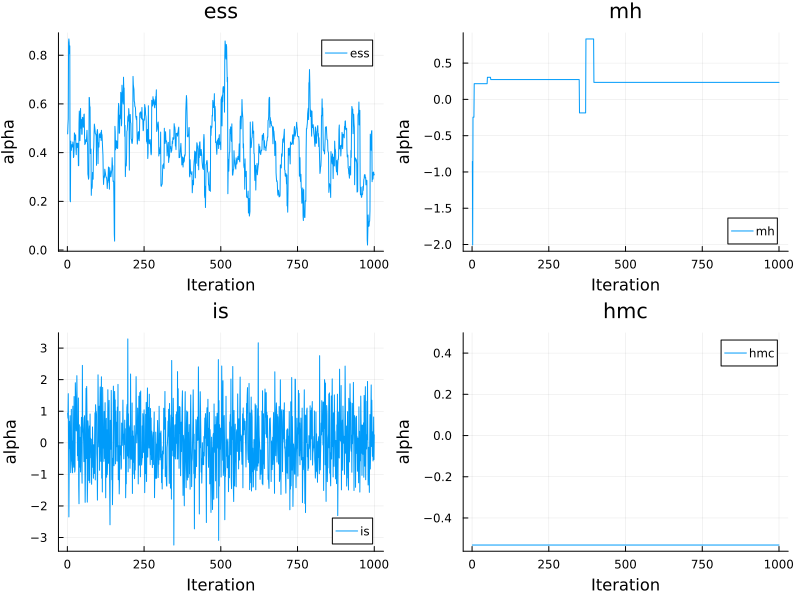

In [5]:
using Gen, Distributions, Plots, StatsPlots, Statistics, Distributions, LinearAlgebra

# Define the linear_regression_model
@gen function linear_regression_model(X, N, K, sigma_alpha2, mu_beta, sigma_beta2, lambda_sigma)
    alpha ~ normal(0, sqrt(sigma_alpha2))  # Intercept
    beta1 ~ normal(mu_beta, sqrt(sigma_beta2))  # Regression coefficient 1
    beta2 ~ normal(mu_beta, sqrt(sigma_beta2))  # Regression coefficient 2
    beta3 ~ normal(mu_beta, sqrt(sigma_beta2))  # Regression coefficient 3

    nu ~ gamma(2, 10)
    sigma ~ exponential(lambda_sigma)

    for i in 1:N
        mu_i = alpha + X[i, 1] * beta1 + X[i, 2] * beta2 + X[i, 3] * beta3
        {(:y, i)} ~ normal(mu_i, sigma)
    end
end

@gen function proposal()
    # Sample alpha and beta from a proposal distribution
    alpha ~ normal(0, 1)  # Proposal for alpha
    beta = [{(:beta, i)} ~ normal(0, 1) for i in 1:3]  # Proposal for beta
    return (alpha, beta)  # Return the proposed values
end

# Generalized Elliptical Slice Sampling (ESS)
function elliptical_slice_sampling(tr, model, args, observations, addresses, prior_dict)
    # Current parameter value(s) for the selected addresses
    current_values = [get_choices(tr)[addr] for addr in addresses]

    # Extract prior mean (m0) and variance (t2) for each selected address
    prior_means = []
    prior_vars = []
    for addr in addresses
        # Get the prior distribution for the selected address
        prior_dist = prior_dict[addr]
        # Extract mean and variance from the prior distribution
        if prior_dist isa Normal
            push!(prior_means, prior_dist.μ)
            push!(prior_vars, prior_dist.σ^2)
        else
            error("Prior distribution for $addr is not Normal. ESS requires Normal priors.")
        end
    end

    # Standard deviations for the priors
    prior_stds = sqrt.(prior_vars)

    # Center the current values so the priors are ~N(0, prior_std^2)
    current_values_offset = current_values .- prior_means

    # Sample a random "direction" from the same priors: N(0, prior_std^2)
    nu = prior_stds .* randn(length(current_values))

    # Current log probability (includes prior + likelihood)
    logp_cur = Gen.get_score(tr)

    # Slice threshold: uniformly pick a threshold below logp_cur
    logy = logp_cur + log(rand())

    # Draw an initial angle
    theta = 2π * rand()
    # Bracket is [theta - 2π, theta]
    theta_min = theta - 2π
    theta_max = theta

    # Elliptical slice loop
    while true
        # Proposed offset via "rotation"
        proposed_offset = current_values_offset .* cos(theta) + nu .* sin(theta)
        # Shift back by prior means
        proposed_values = prior_means .+ proposed_offset

        # Create a ChoiceMap with the proposed values
        temp_cm = Gen.choicemap()
        for (i, addr) in enumerate(addresses)
            temp_cm[addr] = proposed_values[i]
        end

        # Attempt to update the trace with the new values
        (temp_tr, _, re_score) = Gen.update(tr, args, (), temp_cm)

        # Ensure re_score is a numeric type
        re_score = Float64(Gen.get_score(temp_tr))

        if re_score > logy
            # Accept the proposal
            return temp_tr
        else
            # Shrink the bracket
            if theta < 0
                theta_min = theta
            else
                theta_max = theta
            end
            # Sample a new angle within the bracket
            theta = rand() * (theta_max - theta_min) + theta_min
        end
    end
end

# Function to compute log likelihood
function compute_log_likelihood(traces)
    log_likelihoods = [get_score(tr) for tr in traces]
    mean_log_likelihood = logmeanexp(log_likelihoods)
    return mean_log_likelihood
end

# Function to run inference
function run_inference(method, model, args, observations, addresses, prior_dict, num_samples)
    traces = []
    if method == :ess || method == :mh || method == :hmc
        (tr, _) = generate(model, args, observations)
        for iter=1:num_samples
            if method == :ess
                tr = elliptical_slice_sampling(tr, model, args, observations, addresses, prior_dict)
            elseif method == :mh
                (tr, _) = mh(tr, select(addresses...))
            elseif method == :hmc
                (tr, _) = hmc(tr, select(addresses...))
            end
            push!(traces, tr)
        end
    elseif method == :is
        # Importance sampling generates a vector of traces
        (new_traces, _) = importance_sampling(model, args, observations, proposal, (), num_samples)
        # Append each trace to the traces array
        for tr in new_traces
            push!(traces, tr)
        end
    end
    return traces
end

# Example usage
function main()
    # Define the model arguments
    N = 100  # Number of data points
    K = 3    # Number of predictors
    X = rand(N, K)  # Design matrix
    sigma_alpha2 = 1.0  # Prior variance for alpha
    mu_beta = 0.0       # Prior mean for beta
    sigma_beta2 = 1.0   # Prior variance for beta
    lambda_sigma = 1.0  # Rate parameter for sigma

    args = (X, N, K, sigma_alpha2, mu_beta, sigma_beta2, lambda_sigma)

    # Define the observations (constraints)
    ys = rand(N)  # Simulated y values
    observations = Gen.choicemap()
    for (i, y) in enumerate(ys)
        observations[(:y, i)] = y
    end

    # Define the addresses of variables to update
    addresses = [:alpha, :beta1, :beta2, :beta3]

    # Define the prior dictionary using addresses as keys
    prior_dict = Dict(
        :alpha => Normal(0, sqrt(sigma_alpha2)),
        :beta1 => Normal(mu_beta, sqrt(sigma_beta2)),
        :beta2 => Normal(mu_beta, sqrt(sigma_beta2)),
        :beta3 => Normal(mu_beta, sqrt(sigma_beta2))
    )

    # Run inference for all methods
    methods = [:ess, :mh, :is, :hmc]
    results = Dict()
    for method in methods
        println("Running $method...")
        @time traces = run_inference(method, linear_regression_model, args, observations, addresses, prior_dict, 1000)
        results[method] = traces
    end

    # Compare log likelihood
    for method in methods
        mean_log_likelihood = compute_log_likelihood(results[method])
        println("Log Likelihood ($method): ", mean_log_likelihood)
    end

    # Plot traces for alpha
    plt = plot(layout=(2, 2), size=(800, 600))
    for (i, method) in enumerate(methods)
        alpha_samples = [get_choices(tr)[:alpha] for tr in results[method]]
        plot!(plt[i], alpha_samples, xlabel="Iteration", ylabel="alpha", label=string(method), title=string(method))
    end
    display(plt)
end

# Run the main function
main()

In [ ]:
Eight_school

Running ess...
  0.324477 seconds (1.86 M allocations: 68.540 MiB, 12.21% gc time, 64.44% compilation time)
Running mh...
  0.027133 seconds (222.51 k allocations: 8.959 MiB, 47.35% compilation time)
Running is...
  0.033567 seconds (262.54 k allocations: 13.601 MiB, 65.28% compilation time)
Running hmc...
  1.154488 seconds (9.39 M allocations: 366.298 MiB, 6.18% gc time, 3.13% compilation time)
Log Likelihood (ess): -45.02256902678162
Log Likelihood (mh): -45.939825993016456
Log Likelihood (is): -47.31495189268713
Log Likelihood (hmc): -46.39928480745786


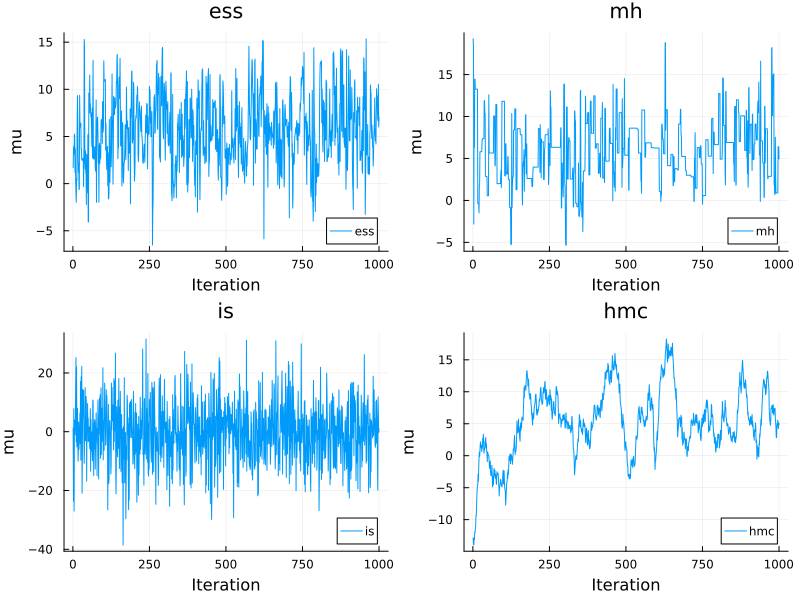

In [24]:
using Gen, Distributions, Plots, StatsPlots, Statistics, Distributions, LinearAlgebra

# Model definition remains unchanged
@gen function eight_school_model(sigma)
    
    mu ~ normal(0, 10)
   
    tau ~ normal(2, 5)  # Half-Cauchy would need different implementation
    
        eta1 ~ normal(0,1)
   
        eta2 ~  normal(0,1)
        eta3 ~ normal(0,1)
   
        eta4 ~ normal(0,1)
        eta5 ~ normal(0,1)
        eta6 ~ normal(0,1)
        eta7 ~ normal(0,1)
        eta8 ~ normal(0,1)
   
    list_of_Eta = [eta1, eta2, eta3, eta4, eta5, eta6,eta7, eta8]
    
    

    
    for i in 1:length(sigma)
        theta = mu + tau * list_of_Eta[i]
        {(:y, i)} ~ normal(theta, sigma[i])
    end
end
@gen function proposal()
    # Sample alpha and beta from a proposal distribution
    mu ~ normal(0, 10)  # Proposal for alpha
    tau ~ normal(2,5)  # Proposal for beta
    eta = [{(:eta, i)} ~ normal(0, 1) for i in 1:8]
    return (mu, tau, eta)  # Return the proposed values
end

# Generalized Elliptical Slice Sampling (ESS)
function elliptical_slice_sampling(tr, model, args, observations, addresses, prior_dict)
    # Current parameter value(s) for the selected addresses
    current_values = [get_choices(tr)[addr] for addr in addresses]

    # Extract prior mean (m0) and variance (t2) for each selected address
    prior_means = []
    prior_vars = []
    for addr in addresses
        # Get the prior distribution for the selected address
        prior_dist = prior_dict[addr]
        # Extract mean and variance from the prior distribution
        if prior_dist isa Normal
            push!(prior_means, prior_dist.μ)
            push!(prior_vars, prior_dist.σ^2)
        else
            error("Prior distribution for $addr is not Normal. ESS requires Normal priors.")
        end
    end

    # Standard deviations for the priors
    prior_stds = sqrt.(prior_vars)

    # Center the current values so the priors are ~N(0, prior_std^2)
    current_values_offset = current_values .- prior_means

    # Sample a random "direction" from the same priors: N(0, prior_std^2)
    nu = prior_stds .* randn(length(current_values))

    # Current log probability (includes prior + likelihood)
    logp_cur = Gen.get_score(tr)

    # Slice threshold: uniformly pick a threshold below logp_cur
    logy = logp_cur + log(rand())

    # Draw an initial angle
    theta = 2π * rand()
    # Bracket is [theta - 2π, theta]
    theta_min = theta - 2π
    theta_max = theta

    # Elliptical slice loop
    while true
        # Proposed offset via "rotation"
        proposed_offset = current_values_offset .* cos(theta) + nu .* sin(theta)
        # Shift back by prior means
        proposed_values = prior_means .+ proposed_offset

        # Create a ChoiceMap with the proposed values
        temp_cm = Gen.choicemap()
        for (i, addr) in enumerate(addresses)
            temp_cm[addr] = proposed_values[i]
        end

        # Attempt to update the trace with the new values
        (temp_tr, _, re_score) = Gen.update(tr, args, (), temp_cm)

        # Ensure re_score is a numeric type
        re_score = Float64(Gen.get_score(temp_tr))

        if re_score > logy
            # Accept the proposal
            return temp_tr
        else
            # Shrink the bracket
            if theta < 0
                theta_min = theta
            else
                theta_max = theta
            end
            # Sample a new angle within the bracket
            theta = rand() * (theta_max - theta_min) + theta_min
        end
    end
end

# Function to compute log likelihood
function compute_log_likelihood(traces)
    log_likelihoods = [get_score(tr) for tr in traces]
    mean_log_likelihood = logmeanexp(log_likelihoods)
    return mean_log_likelihood
end

# Function to run inference
function run_inference(method, model, args, observations, addresses, prior_dict, num_samples)
    traces = []
    if method == :ess || method == :mh || method == :hmc
        (tr, _) = generate(model, args, observations)
        for iter=1:num_samples
            if method == :ess
                tr = elliptical_slice_sampling(tr, model, args, observations, addresses, prior_dict)
            elseif method == :mh
                (tr, _) = mh(tr, select(addresses...))
            elseif method == :hmc
                (tr, _) = hmc(tr, select(addresses...))
            end
            push!(traces, tr)
        end
    elseif method == :is
        # Importance sampling generates a vector of traces
        (new_traces, _) = importance_sampling(model, args, observations, proposal, (), num_samples)
        # Append each trace to the traces array
        for tr in new_traces
            push!(traces, tr)
        end
    end
    return traces
end

# Example usage
function main()
    # Define the model arguments
    N = 8  # Number of data points
  
    
   
    
    sigma = [15, 10, 16, 11, 9, 11, 10, 18]
    args = (sigma,)

    # Define the observations (constraints)
    ys =  [28, 8, -3, 7, -1, 1, 18, 12]
    observations = Gen.choicemap()
    for (i, y) in enumerate(ys)
        observations[(:y, i)] = y
    end

    # Define the addresses of variables to update
    addresses = [:mu, :tau, :eta1, :eta2, :eta3, :eta4, :eta5, :eta6, :eta7, :eta8]

    # Define the prior dictionary using addresses as keys
    prior_dict = Dict(
        :mu => Normal(0, 10),
        :tau => Normal(2,5),
        :eta1 => Normal(0,1),
        :eta2 => Normal(0,1),
        :eta3 => Normal(0,1),
        :eta4 => Normal(0,1),
        :eta5 => Normal(0,1),
        :eta6 => Normal(0,1),
        :eta7 => Normal(0,1),
        :eta8 => Normal(0,1)
        
       
    )

    # Run inference for all methods
    methods = [:ess, :mh, :is, :hmc]
    results = Dict()
    for method in methods
        println("Running $method...")
        @time traces = run_inference(method, eight_school_model, args, observations, addresses, prior_dict, 1000)
        results[method] = traces
    end

    # Compare log likelihood
    for method in methods
        mean_log_likelihood = compute_log_likelihood(results[method])
        println("Log Likelihood ($method): ", mean_log_likelihood)
    end

    # Plot traces for alpha
    plt = plot(layout=(2, 2), size=(800, 600))
    for (i, method) in enumerate(methods)
        mu_samples = [get_choices(tr)[:mu] for tr in results[method]]
        plot!(plt[i], mu_samples, xlabel="Iteration", ylabel="mu", label=string(method), title=string(method))
    end
    display(plt)
end

# Run the main function
main()

Poisson Model

In [ ]:
@gen function poissons(m0, t2)
    logtheta ~ normal(m0, sqrt(t2))
    y ~ poisson(logtheta)
    return y
end

function make_constraints(ys)
    constraints = Gen.choicemap()
    constraints[:y] = ys
    return constraints
end;

function logmeanexp(scores)
    logsumexp(scores) - log(length(scores))
end;

function elliptical_slice_1d(tr,
                             model,
                             m0,
                             t2)

    # Current parameter value
    x_cur = get_choices(tr)[:logtheta]
    # Standard deviation for the prior:
    prior_std = sqrt(t2)
    # Center it so prior is ~N(0, prior_std^2)
    x_offset_cur = x_cur - m0

    # Sample a random "direction" from the same prior:
    # i.e. from N(0, prior_std^2)
    nu = prior_std * randn()

    # Current log probability
    logp_cur = Gen.get_score(tr)  # includes prior + likelihood

    # Slice threshold
    logy = logp_cur + log(rand())  # uniformly picking a threshold below logp_cur

    # Draw an initial angle
    theta = 2π * rand()
    # Bracket is [theta - 2π, theta]
    theta_min = theta - 2π
    theta_max = theta

    # Elliptical slice loop
    while true
        # Proposed offset via "rotation"
        x_offset_prop = x_offset_cur * cos(theta) + nu * sin(theta)
        # Shift back by m0
        x_prop = m0 + x_offset_prop

        # Attempt to update trace with the new x_prop
        # "update" will re-simulate if needed and compute the new log score.
        # We'll keep the same (m0, t2) arguments.
        temp_cm = Gen.choicemap((:logtheta => x_prop))
        (temp_tr, _, re_score) = Gen.update(
            tr, 
            (m0, t2), (),   # arguments to the generative function
            temp_cm
        )

        # Ensure re_score is a numeric type
        re_score = Float64(Gen.get_score(temp_tr))

        if re_score > logy
            # Accept the proposal
            return temp_tr
        else
            # Shrink the bracket
            if theta < 0
                theta_min = theta
            else
                theta_max = theta
            end
            # Sample a new angle within the bracket
            theta = rand() * (theta_max - theta_min) + theta_min
        end
    end
end


# Define a proposal distribution for importance sampling
@gen function proposal(m0, t2)
    logtheta ~ normal(m0, sqrt(t2))  # Same as the prior
end

# Parameters
m0 = 50.0  
t2 = 0.1      
ys = 48.0       
obs = Gen.choicemap((:y => ys))  # Constraints
num_samples = 1000  # Number of samples

# Function to run inference with a given sampler
function run_inference(method, model, args, observations, num_samples)
    traces = []
    if method == :ess || method == :mh || method == :hmc
        (tr, _) = generate(model, args, observations)
        for iter=1:num_samples
            if method == :ess
                tr = elliptical_slice_1d(tr, model, args[1], args[2])
            elseif method == :mh
                (tr, _) = mh(tr, select(:logtheta))
            elseif method == :hmc
                (tr, _) = hmc(tr, select(:logtheta))
            end
            push!(traces, tr)
        end
    elseif method == :is
        # Importance sampling generates a vector of traces
        (new_traces, _) = importance_sampling(model, args, observations, proposal, args, num_samples)
        # Append each trace to the traces array
        for tr in new_traces
            push!(traces, tr)
        end
    end
    return traces
end

# Run inference for each method
# methods = [:ess, :mh, :is, :hmc]
methods = [:ess, :mh, :hmc, :is]
results = Dict()
for method in methods
    println("Running $method...")
    @time traces = run_inference(method, poissons, (m0, t2), obs, num_samples)
    results[method] = traces
end

# Plot trace plots for comparison
plt = plot(layout=(2, 2), size=(800, 600))
for (i, method) in enumerate(methods)
    # Extract logtheta values from each trace
    logtheta_samples = [get_choices(tr)[:logtheta] for tr in results[method]]
    # Plot the trace
    plot!(plt[i], logtheta_samples, xlabel="Iteration", ylabel="logtheta", label=string(method), title=string(method))
end
display(plt)

# Compare log probability estimates
for method in methods
    scores = [get_score(tr) for tr in results[method]]
    println("Log probability ($method): ", logmeanexp(scores))
end

Log Poisson Model


In [ ]:
@gen function log_poisson(m0, t2)
    # Draw log(theta) from Normal(m0, sqrt(t2)):
    logtheta ~ normal(m0, sqrt(t2))
    # Draw y from Poisson(exp(logtheta)):
    y ~ poisson(exp(logtheta))
    return y
end

function make_constraints(ys)
    constraints = Gen.choicemap()
    constraints[:y] = ys
    return constraints
end;

function logmeanexp(scores)
    logsumexp(scores) - log(length(scores))
end;

function elliptical_slice_1d(tr,
                             model,
                             m0,
                             t2)

    # Current parameter value
    x_cur = get_choices(tr)[:logtheta]
    # Standard deviation for the prior:
    prior_std = sqrt(t2)
    # Center it so prior is ~N(0, prior_std^2)
    x_offset_cur = x_cur - m0

    # Sample a random "direction" from the same prior:
    # i.e. from N(0, prior_std^2)
    nu = prior_std * randn()

    # Current log probability
    logp_cur = Gen.get_score(tr)  # includes prior + likelihood

    # Slice threshold
    logy = logp_cur + log(rand())  # uniformly picking a threshold below logp_cur

    # Draw an initial angle
    theta = 2π * rand()
    # Bracket is [theta - 2π, theta]
    theta_min = theta - 2π
    theta_max = theta

    # Elliptical slice loop
    while true
        # Proposed offset via "rotation"
        x_offset_prop = x_offset_cur * cos(theta) + nu * sin(theta)
        # Shift back by m0
        x_prop = m0 + x_offset_prop

        # Attempt to update trace with the new x_prop
        # "update" will re-simulate if needed and compute the new log score.
        # We'll keep the same (m0, t2) arguments.
        temp_cm = Gen.choicemap((:logtheta => x_prop))
        (temp_tr, _, re_score) = Gen.update(
            tr, 
            (m0, t2), (),   # arguments to the generative function
            temp_cm
        )

        # Ensure re_score is a numeric type
        re_score = Float64(Gen.get_score(temp_tr))

        if re_score > logy
            # Accept the proposal
            return temp_tr
        else
            # Shrink the bracket
            if theta < 0
                theta_min = theta
            else
                theta_max = theta
            end
            # Sample a new angle within the bracket
            theta = rand() * (theta_max - theta_min) + theta_min
        end
    end
end


# Define a proposal distribution for importance sampling
@gen function proposal(m0, t2)
    logtheta ~ normal(m0, sqrt(t2))  # Same as the prior
end

# Parameters
m0 = log(50.0)  
t2 = 0.1      
ys = 48.0       
obs = Gen.choicemap((:y => ys))  # Constraints
num_samples = 2000  # Number of samples

# Function to run inference with a given sampler
function run_inference(method, model, args, observations, num_samples)
    traces = []
    if method == :ess || method == :mh || method == :hmc
        (tr, _) = generate(model, args, observations)
        for iter=1:num_samples
            if method == :ess
                tr = elliptical_slice_1d(tr, model, args[1], args[2])
            elseif method == :mh
                (tr, _) = mh(tr, select(:logtheta))
            elseif method == :hmc
                (tr, _) = hmc(tr, select(:logtheta))
            end
            push!(traces, tr)
        end
    elseif method == :is
        # Importance sampling generates a vector of traces
        (new_traces, _) = importance_sampling(model, args, observations, proposal, args, num_samples)
        # Append each trace to the traces array
        for tr in new_traces
            push!(traces, tr)
        end
    end
    return traces
end

# Run inference for each method
# methods = [:ess, :mh, :is, :hmc]
methods = [:ess, :mh, :hmc, :is]
results = Dict()
for method in methods
    println("Running $method...")
    @time traces = run_inference(method, log_poisson, (m0, t2), obs, num_samples)
    results[method] = traces
end

# Plot trace plots for comparison
plt = plot(layout=(2, 2), size=(800, 600))
for (i, method) in enumerate(methods)
    # Extract logtheta values from each trace
    logtheta_samples = [get_choices(tr)[:logtheta] for tr in results[method]]
    # Plot the trace
    plot!(plt[i], logtheta_samples, xlabel="Iteration", ylabel="logtheta", label=string(method), title=string(method))
end
display(plt)

# Compare log probability estimates
for method in methods
    scores = [get_score(tr) for tr in results[method]]
    println("Log probability ($method): ", logmeanexp(scores))
end

Sine Line Model

In [ ]:
using Gen, Distributions, Plots, StatsPlots, Statistics, Distributions, LinearAlgebra
 using MCMCChains: ess


@gen function sine_model_fancy_transformed(xs::Vector{Float64})
    # Sample Gaussian variables
    z_amplitude ~ normal(0, 1)  # Gaussian variable for amplitude
    z_period ~ normal(0, 1)     # Gaussian variable for period
    z_phase ~ normal(0, 1)      # Gaussian variable for phase
    z_noise ~ normal(0, 1)      # Gaussian variable for noise

    # Transform Gaussian variables to desired distributions
    amplitude = quantile(Gamma(1, 1), cdf(Normal(0, 1), z_amplitude))  # Transform to Gamma(1, 1)
    period = quantile(Gamma(5, 1), cdf(Normal(0, 1), z_period))        # Transform to Gamma(5, 1)
    phase = quantile(Uniform(0, 2π), cdf(Normal(0, 1), z_phase))       # Transform to Uniform(0, 2π)
    noise = quantile(Gamma(1, 1), cdf(Normal(0, 1), z_noise))          # Transform to Gamma(1, 1)
    function sine(x)
        return amplitude * sin(((2*pi*x)/period) + phase)
    end

    for (i, x) in enumerate(xs)
        {(:y, i)} ~ normal(sine(x), noise)
    end
    return sine
end

@gen function line_model_fancy(xs::Vector{Float64})
    slope = ({:slope} ~ normal(0, 1))
    intercept = ({:intercept} ~ normal(0, 2))
    
    function y(x)
        return slope * x + intercept
    end
    
    noise = ({:noise} ~ gamma(1, 1))
    for (i, x) in enumerate(xs)
        {(:y, i)} ~ normal(slope * x + intercept, noise)
    end
    return y
end;

@gen function combined_model_transformed(xs::Vector{Float64})
    if ({:is_line} ~ bernoulli(0.5))
        # Call line_model_fancy on xs
        return ({*} ~ line_model_fancy(xs))
    else
        # Call sine_model_fancy_transformed on xs
        return ({*} ~ sine_model_fancy_transformed(xs))
    end
end

function elliptical_slice_sampling(tr, model, args, observations, addresses, prior_dict)
    # Current parameter value(s) for the selected addresses
    current_values = [get_choices(tr)[addr] for addr in addresses]

    # Extract prior mean (m0) and variance (t2) for each selected address
    prior_means = []
    prior_vars = []
    for addr in addresses
        # Get the prior distribution for the selected address
        prior_dist = prior_dict[addr]
        # Extract mean and variance from the prior distribution
        if prior_dist isa Normal
            push!(prior_means, prior_dist.μ)
            push!(prior_vars, prior_dist.σ^2)
        else
            error("Prior distribution for $addr is not Normal. ESS requires Normal priors.")
        end
    end

    # Standard deviations for the priors
    prior_stds = sqrt.(prior_vars)

    # Center the current values so the priors are ~N(0, prior_std^2)
    current_values_offset = current_values .- prior_means

    # Sample a random "direction" from the same priors: N(0, prior_std^2)
    nu = prior_stds .* randn(length(current_values))

    # Current log probability (includes prior + likelihood)
    logp_cur = Gen.get_score(tr)

    # Slice threshold: uniformly pick a threshold below logp_cur
    logy = logp_cur + log(rand())

    # Draw an initial angle
    theta = 2π * rand()
    # Bracket is [theta - 2π, theta]
    theta_min = theta - 2π
    theta_max = theta

    # Elliptical slice loop
    while true
        # Proposed offset via "rotation"
        proposed_offset = current_values_offset .* cos(theta) + nu .* sin(theta)
        # Shift back by prior means
        proposed_values = prior_means .+ proposed_offset

        # Create a ChoiceMap with the proposed values
        temp_cm = Gen.choicemap()
        for (i, addr) in enumerate(addresses)
            temp_cm[addr] = proposed_values[i]
        end

        # Attempt to update the trace with the new values
        (temp_tr, _, re_score) = Gen.update(tr, args, (), temp_cm)

        # Ensure re_score is a numeric type
        re_score = Float64(Gen.get_score(temp_tr))

        if re_score > logy
            # Accept the proposal
            return temp_tr
        else
            # Shrink the bracket
            if theta < 0
                theta_min = theta
            else
                theta_max = theta
            end
            # Sample a new angle within the bracket
            theta = rand() * (theta_max - theta_min) + theta_min
        end
    end
end

function logmeanexp(scores)
    logsumexp(scores) - log(length(scores))
end;

function run_inference(method, model, args, observations, addresses, prior_dict, num_samples)
    traces = []
    if method == :is
        (traces, _) = importance_sampling(model, args, observations, num_samples)
    else
        # MCMC methods: run iteratively
        (tr, _) = generate(model, args, observations)
        for iter = 1:num_samples
            if method == :ess
                if get_choices(tr)[:is_line]
                    tr = elliptical_slice_sampling(tr, model, args, observations, addresses[:line], prior_dict)
                else
                    tr = elliptical_slice_sampling(tr, model, args, observations, addresses[:sine], prior_dict)
                end
            elseif method == :mh
                if get_choices(tr)[:is_line]
                    (tr, _) = mh(tr, select(addresses[:line]...))
                else
                    (tr, _) = mh(tr, select(addresses[:sine]...))
                end
            end
            push!(traces, tr)
        end
    end
    return traces
end


function main()

    # Define the input data
    xs = [-5., -4., -3., -2., -1., 0., 1., 2., 3., 4., 5.];

    # Define the model arguments
    args = (xs,)

    # Define the observations (constraints)
    ys = [6.75003, 6.1568, 4.26414, 1.84894, 3.09686, 1.94026, 1.36411, -0.83959, -0.976, -1.93363, -2.91303];
    ys_sine = [2.89, 2.22, -0.612, -0.522, -2.65, -0.133, 2.70, 2.77, 0.425, -2.11, -2.76];
    observations = Gen.choicemap()
    for (i, y) in enumerate(ys_sine)
        observations[(:y, i)] = y
    end
    observations[:is_line] = 0

    # Define the addresses of variables to update
    addresses = Dict(
        :line => [:slope, :intercept],  # Addresses for line_model_fancy
        :sine => [:z_amplitude, :z_period, :z_phase, :z_noise]  # Addresses for sine_model_fancy_transformed
    )

    # Define the prior dictionary
    prior_dict = Dict(
        :slope => Normal(0, 1),          # Prior for slope
        :intercept => Normal(0, 2),      # Prior for intercept
        :z_amplitude => Normal(0, 1),    # Prior for z_amplitude
        :z_period => Normal(0, 1),       # Prior for z_period
        :z_phase => Normal(0, 1),        # Prior for z_phase
        :z_noise => Normal(0, 1)         # Prior for z_noise
    )

    # Run inference
    num_samples = 1000
    methods = [:ess, :mh, :is]
    results = Dict()
    for method in methods
        println("Running $method...")
        @time traces = run_inference(method, combined_model_transformed, args, observations, addresses, prior_dict, num_samples)
        results[method] = traces
    end

    # Compare log probability estimates
    for method in methods
        scores = [get_score(tr) for tr in results[method]]
        println("Log probability ($method): ", logmeanexp(scores))
    end

    # # Compute Effective Sample Size (ESS)
    # for method in methods
    #     # Extract :slope values from each trace (or any other parameter of interest)
    #     slope_samples = Float64[get_choices(tr)[:slope] for tr in results[method] if has_value(get_choices(tr), :slope)]
    #     # Compute ESS
    #     ess_value = ess(slope_samples)
    #     println("Effective Sample Size ($method): ", ess_value)
    # end

    # Generate predictions for a single trace
    function generate_predictions(tr, xs)
        if has_value(get_choices(tr), :slope)
            # Line mode
            slope = get_choices(tr)[:slope]
            intercept = get_choices(tr)[:intercept]
            noise = get_choices(tr)[:noise]
            return slope .* xs .+ intercept .+ rand(Normal(0, noise), length(xs))
        else
            # Sine mode
            amplitude = quantile(Gamma(1, 1), cdf(Normal(0, 1), get_choices(tr)[:z_amplitude]))
            period = quantile(Gamma(5, 1), cdf(Normal(0, 1), get_choices(tr)[:z_period]))
            phase = quantile(Uniform(0, 2π), cdf(Normal(0, 1), get_choices(tr)[:z_phase]))
            noise = quantile(Gamma(1, 1), cdf(Normal(0, 1), get_choices(tr)[:z_noise]))
            println(period)
            return amplitude .* sin.((2π .* xs) ./ period .+ phase) .+ rand(Normal(0, noise), length(xs))
        end
    end

    # Plot observed vs predicted data
    plt = plot()
    for method in methods
        # Generate predictions for the first trace (or average over multiple traces)
        predictions = generate_predictions(last(results[method]), xs)
        plot!(plt, xs, predictions, label=string(method), alpha=0.5)
    end
    # Plot observed data
    scatter!(plt, xs, ys_sine, label="Observed Data", color=:black)
    display(plt)
end


# Run the main function
main()
